## <b> Crisis Recovery Analysis for QuickBite Express </b>

### Section 1 : 📌 Problem Definition & Objective

- QuickBite Express, a food-tech startup, is experiencing a significant business decline following a crisis triggered by food safety concerns and service disruptions. The company is facing rapid customer churn, reduced order volumes, declining customer satisfaction, loss of restaurant partners, and increased customer acquisition costs. 
- The core problem is to analyze the impact of this crisis on customer behavior, operations, and partner ecosystem, and identify actionable insights to support recovery and strategic decision-making.


### Section 2 :📥 Environment Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns


In [2]:
df_customers = pd.read_csv('dim_customer.csv',parse_dates=['signup_date'])
df_restaurant = pd.read_csv('dim_restaurant.csv')
df_delivery_partner =pd.read_csv('dim_delivery_partner_.csv')
df_menu =pd.read_csv('dim_menu_item.csv')
df_delivery_performance = pd.read_csv('fact_delivery_performance.csv')
df_order_items = pd.read_csv('fact_order_items.csv')
df_orders = pd.read_csv('fact_orders.csv',parse_dates=['order_timestamp'])
df_ratings = pd.read_csv('fact_ratings.csv',parse_dates=['review_timestamp'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25360\1955079177.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_customers = pd.read_csv('dim_customer.csv',parse_dates=['signup_date'])


### Section 3 :🧹 Data Cleaning

In [3]:
def basic_clean(df):
    df.columns = df.columns.str.lower().str.strip()# column names to be in lowercase
    df.drop_duplicates(inplace=True)
    df.dropna(how='all',inplace=True)
    return df

df_orders = basic_clean(df_orders)
df_customers = basic_clean(df_customers)
df_restaurant = basic_clean(df_restaurant)
df_delivery_partner = basic_clean(df_delivery_partner)
df_menu = basic_clean(df_menu)
df_delivery_performance = basic_clean(df_delivery_performance)
df_order_items = basic_clean(df_order_items)
df_ratings = basic_clean(df_ratings)

In [4]:
df_orders['is_cancelled'] = df_orders['is_cancelled'].astype('category')
df_orders['is_cod'] = df_orders['is_cod'].astype('category')

In [5]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             149166 non-null  str           
 1   customer_id          149166 non-null  str           
 2   restaurant_id        149166 non-null  str           
 3   delivery_partner_id  143531 non-null  str           
 4   order_timestamp      149166 non-null  datetime64[us]
 5   subtotal_amount      149166 non-null  float64       
 6   discount_amount      149166 non-null  float64       
 7   delivery_fee         149166 non-null  float64       
 8   total_amount         149166 non-null  float64       
 9   is_cod               149166 non-null  category      
 10  is_cancelled         149166 non-null  category      
dtypes: category(2), datetime64[us](1), float64(4), str(4)
memory usage: 10.5 MB


### Section 4 : 📊 Exploratory Data Analysis

#### 4.1 Overall Business Trend

In [6]:
df_orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N


In [7]:
df_orders.info()
#checking for null values
#checking for appropriate column's datatype

<class 'pandas.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             149166 non-null  str           
 1   customer_id          149166 non-null  str           
 2   restaurant_id        149166 non-null  str           
 3   delivery_partner_id  143531 non-null  str           
 4   order_timestamp      149166 non-null  datetime64[us]
 5   subtotal_amount      149166 non-null  float64       
 6   discount_amount      149166 non-null  float64       
 7   delivery_fee         149166 non-null  float64       
 8   total_amount         149166 non-null  float64       
 9   is_cod               149166 non-null  category      
 10  is_cancelled         149166 non-null  category      
dtypes: category(2), datetime64[us](1), float64(4), str(4)
memory usage: 10.5 MB


In [8]:
df_orders.isna().sum()

order_id                  0
customer_id               0
restaurant_id             0
delivery_partner_id    5635
order_timestamp           0
subtotal_amount           0
discount_amount           0
delivery_fee              0
total_amount              0
is_cod                    0
is_cancelled              0
dtype: int64

In [9]:
print(df_orders['order_id'].is_unique)

True


In [10]:
df_orders['order_timestamp'].dt.year.unique()

array([2025], dtype=int32)

In [11]:
df_orders['month'] = df_orders['order_timestamp'].dt.month
df_orders.tail()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,month
149161,ORD202509003524,CUST080037,REST12269,DP13152,2025-09-30 22:51:00,0.00,0.00,0.00,0.00,N,Y,9
149162,ORD202509007665,CUST014106,REST04052,NaN,2025-09-30 22:52:00,0.00,0.00,0.00,0.00,Y,Y,9
149163,ORD202509007687,CUST181895,REST07289,DP04700,2025-09-30 22:55:00,521.08,85.35,20.67,456.40,N,N,9
149164,ORD202509002029,CUST089114,REST18195,DP12994,2025-09-30 22:58:00,199.13,22.63,20.37,196.87,N,N,9
149165,ORD202509007649,CUST165574,REST04104,DP09675,2025-09-30 22:59:00,271.90,36.82,39.02,274.11,Y,N,9


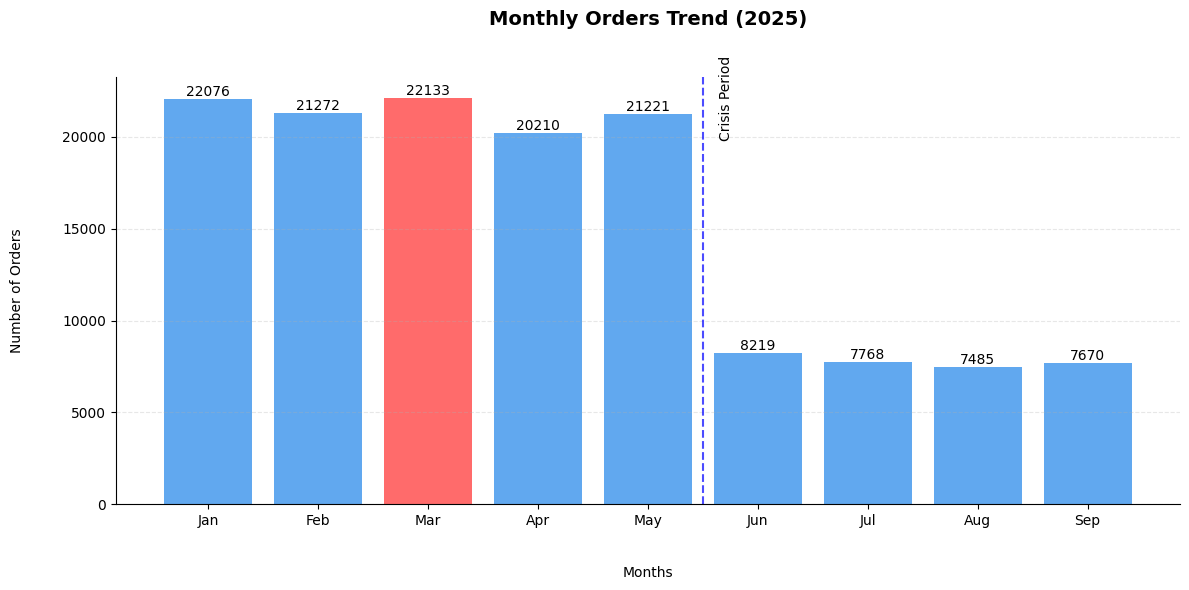

In [12]:
# Monthly order trend
valid_orders = df_orders[df_orders['is_cancelled'] == 'N'] # exclude cancelled orders
trend = valid_orders.groupby('month')['order_id'].size().sort_index()

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep"]

plt.figure(figsize=(12,6))

# Highlight logic (example: max month)
colors = ["#61a8ef"] * len(trend)
max_idx = trend.values.argmax()
colors[max_idx] = '#ff6b6b'

bars = plt.bar(months, trend.values, color=colors)

# Title
plt.title("Monthly Orders Trend (2025)\n\n", fontsize=14, weight='bold')
plt.xlabel("\n\nMonths")
plt.ylabel("Number of Orders\n\n")

# Clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add data labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f'{int(y)}', ha='center', va='bottom', fontsize=10)

plt.axvline(x=4.5, color='blue', linestyle='--', alpha=0.7)
plt.text(4.5, max(trend)*0.9, "\nCrisis Period", rotation=90)

plt.tight_layout()
plt.show()

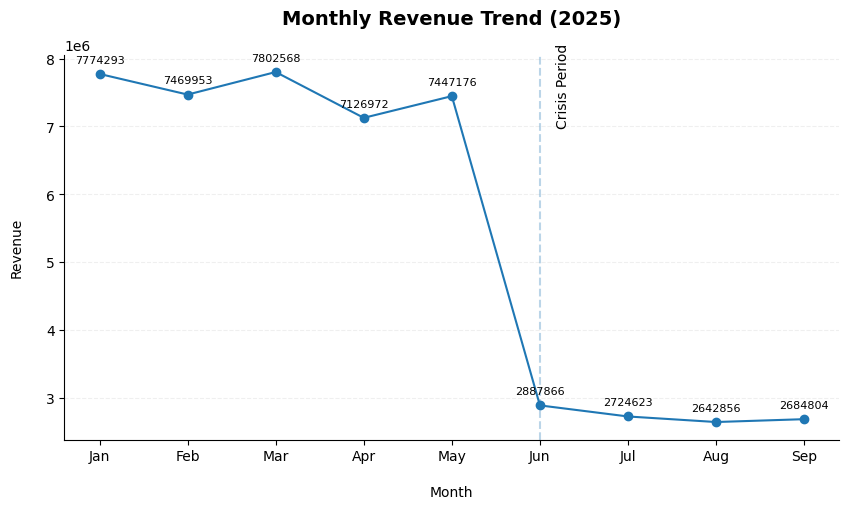

In [13]:
# Monthly Revenue Trend
trend = df_orders.groupby(['month'])['total_amount'].sum()

plt.figure(figsize=(10,5))

# Line chart
plt.plot(months, trend.values, marker='o')

# Title & labels
plt.title("Monthly Revenue Trend (2025)\n", fontsize=14, weight='bold')
plt.ylabel("Revenue\n")
plt.xlabel("\nMonth")

# Clean look
plt.grid(axis='y', linestyle='--',alpha=0.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


for i, value in enumerate(trend.values):
    plt.annotate(
        f'{int(value)}',
        (i, value),
        textcoords="offset points",
        xytext=(0, 8),   # (x_offset, y_offset)
        ha='center',
        fontsize=8
    )
    
plt.axvline(x=5, linestyle='--', alpha=0.3)
plt.text(5, max(trend) * 0.9, "\nCrisis Period", rotation=90)



plt.show()


Phase Definition

- Defining the Crisis Timeline: Creating a categorical "period" column based on the date:
- Pre-Crisis: January – May 2025.
- Crisis: June – September 2025.

In [14]:
def period(ts):
     if ts in range(1,6):
          return 'pre-crisis'
     else:
          return 'crisis'
df_orders['period'] = df_orders['month'].apply(period)
df_orders.head()
df_orders['period'].astype('category')

0         pre-crisis
1         pre-crisis
2         pre-crisis
3         pre-crisis
4         pre-crisis
             ...    
149161        crisis
149162        crisis
149163        crisis
149164        crisis
149165        crisis
Name: period, Length: 149166, dtype: category
Categories (2, str): ['crisis', 'pre-crisis']

In [15]:
df_orders['period'] = df_orders['period'].astype('category')
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             149166 non-null  str           
 1   customer_id          149166 non-null  str           
 2   restaurant_id        149166 non-null  str           
 3   delivery_partner_id  143531 non-null  str           
 4   order_timestamp      149166 non-null  datetime64[us]
 5   subtotal_amount      149166 non-null  float64       
 6   discount_amount      149166 non-null  float64       
 7   delivery_fee         149166 non-null  float64       
 8   total_amount         149166 non-null  float64       
 9   is_cod               149166 non-null  category      
 10  is_cancelled         149166 non-null  category      
 11  month                149166 non-null  int32         
 12  period               149166 non-null  category      
dtypes: category(3), datetime6

In [16]:
total_non_cancelled_orders  = df_orders[df_orders['is_cancelled'] == 'N']['order_id'].count()
print('Total Orders : ',total_non_cancelled_orders )

Total Orders :  138054


In [17]:
total_cancelled_orders = df_orders[df_orders['is_cancelled'] == 'Y']['order_id'].count()
print('Total Cancelled Orders : ',total_cancelled_orders )

Total Cancelled Orders :  11112


In [18]:
# How servere is the decline by orders
order_summary = df_orders[df_orders['is_cancelled'] == 'N'].groupby('period').size()
print(order_summary)
print("\nOrders dropped by :",end=' ')
dropped_orders = order_summary['pre-crisis'] - order_summary['crisis']
print(dropped_orders)
print('Order drop rate : ',dropped_orders / order_summary['pre-crisis'] * 100 )


period
crisis         31142
pre-crisis    106912
dtype: int64

Orders dropped by : 75770
Order drop rate :  70.87137084705178


In [19]:
# How servere is the decline by revenue
revenue_summary = df_orders.groupby('period')['total_amount'].sum()
print(revenue_summary)
print("Revenue dropped by :",end=' ')
dropped_revenue = revenue_summary['pre-crisis'] - revenue_summary['crisis']
print(dropped_revenue)
print('Revenue drop rate : ',dropped_revenue / revenue_summary['pre-crisis'] * 100 )



period
crisis        10940151.31
pre-crisis    37620964.25
Name: total_amount, dtype: float64
Revenue dropped by : 26680812.939999998
Revenue drop rate :  70.92006670190544


#### <b>4.2 Customer Analysis </b>

In [20]:
print(df_customers.shape)
df_customers.head()


(107776, 4)


,customer_id,signup_date,city,acquisition_channel
0,CUST000007,2025-03-21,Pune,Organic
1,CUST000008,2025-02-07,Kolkata,Referral
2,CUST000009,2025-02-25,Delhi,Paid
3,CUST000010,2025-01-28,Hyderabad,Paid
4,CUST000011,2025-01-18,Kolkata,Organic


In [21]:
df_customer_orders = pd.merge(df_orders[
                                ['order_id','customer_id','order_timestamp','total_amount','is_cancelled','month','period']
                                ],
                              df_customers['customer_id'],
                              how='left',
                              on="customer_id")
df_customer_orders.head()

,order_id,customer_id,order_timestamp,total_amount,is_cancelled,month,period
0,ORD202501023439,CUST181110,2025-01-01 12:00:00,466.74,N,1,pre-crisis
1,ORD202501012051,CUST025572,2025-01-01 12:00:00,283.13,N,1,pre-crisis
2,ORD202501019281,CUST179306,2025-01-01 12:00:00,454.61,N,1,pre-crisis
3,ORD202501000124,CUST191820,2025-01-01 12:00:00,293.56,N,1,pre-crisis
4,ORD202501006518,CUST033760,2025-01-01 12:00:00,305.90,N,1,pre-crisis


In [22]:
total_customers = df_customer_orders['customer_id'].nunique()
print('Total Customers : ',total_customers)

Total Customers :  105180


In [23]:
# Customers with atleast one non-cancelled order during any of the phase
# type : dataframe
active_orders = df_customer_orders[df_customer_orders['is_cancelled'] == 'N']
active_orders.head()
total_active_customers = active_orders['customer_id'].nunique()
print('Active Customers: ',total_active_customers)

Active Customers:  99790


In [24]:
# Customers who ordered during crisis period
crisis_customers = set(
    active_orders.loc[active_orders['period'] == 'crisis', 'customer_id']
)
print('Customers who order during crisis : ',len(crisis_customers))
# Customers who ordered during pre-crisis period
pre_crisis_customers = set(
    active_orders.loc[active_orders['period'] == 'pre-crisis', 'customer_id']
)
print('Customers who order before crisis : ',len(pre_crisis_customers))

# Customers who ordered in both periods
common_customers = crisis_customers.intersection(pre_crisis_customers)


print('Common customers/Retained customers : ',len(common_customers))

# Customers drop rate : Customers who ordered before crisis but not during crisis
dropped_customers = pre_crisis_customers - crisis_customers
print('Dropped customers :',len(dropped_customers))
print('Dropped_customer_rate/Churned rate : ',len(dropped_customers)/len(pre_crisis_customers) * 100)

Customers who order during crisis :  28820
Customers who order before crisis :  82862
Common customers/Retained customers :  11892
Dropped customers : 70970
Dropped_customer_rate/Churned rate :  85.64842750597379


##### Customer Segments

1. Loyal Customers : Customers with pre-crisis non caneclled orders >= 5

In [25]:
# Loyal Customers : Set of customer ids
loyal_customers = set(
    active_orders[active_orders['period'] == 'pre-crisis']
    ['customer_id']
    .value_counts()
    .loc[lambda x: x >= 5]
    .index
)

print('Loyal customers:', len(loyal_customers))


Loyal customers: 50


In [26]:
# Loyal customer order average
print('Overall Average :', (total_non_cancelled_orders / total_active_customers).round(1))
loyal_orders = df_customer_orders[df_customer_orders['customer_id'].isin(loyal_customers)]['order_id'].count()
print('Loyal customers Average :', (loyal_orders / len(loyal_customers)).round(1))




Overall Average : 1.4
Loyal customers Average : 5.3


2. New Customers : Customers with first order during crisis

In [27]:
# New customers : Set of customers ids
new_customers = crisis_customers - pre_crisis_customers
print('New customers :',len(new_customers))


New customers : 16928


3. High Value Customers : Top 5% customers by total spend before the crisis

In [28]:
# High value customers : Set of customer_ids
high_value_customers = set(
    df_customer_orders[df_customer_orders['period'] == 'pre-crisis']
    .groupby('customer_id')['total_amount']
    .sum()
    .loc[lambda x: x >= x.quantile(0.95)]
    .index
)

print("Number of high-value customers:", len(high_value_customers))

Number of high-value customers: 4342


In [29]:
# Revenue contributed by high value customers
vip_revenue = df_customer_orders[df_customer_orders['customer_id'].isin(high_value_customers)].groupby('period')['total_amount'].sum()
#total revenue
total_revenue = df_orders.groupby('period')['total_amount'].sum()
print("Total Revenue : ",total_revenue)
print("\nRevenue by VIP's : ",vip_revenue)
print("\nRevenue contribution percentage : ",vip_revenue/total_revenue * 100)


Total Revenue :  period
crisis        10940151.31
pre-crisis    37620964.25
Name: total_amount, dtype: float64

Revenue by VIP's :  period
crisis         237424.23
pre-crisis    4897455.17
Name: total_amount, dtype: float64

Revenue contribution percentage :  period
crisis         2.170210
pre-crisis    13.017888
Name: total_amount, dtype: float64


4. At-Risk Customers : Ordered in both periods but with reduced activity
- placed more than 3 orders before crisis
- placed only 1 order during crisis

In [30]:
# Engagement comparison of retained customers pre-crisis vs crisis
engagement_summary = df_customer_orders[(df_customer_orders['customer_id'].isin(common_customers))].groupby(['customer_id','period'])
engagement_summary = engagement_summary['order_id'].count().unstack()
at_risk_customers= set(
    engagement_summary[
        (engagement_summary['crisis'] == 1) & (engagement_summary['pre-crisis'] >= 3)
        ]
        .index
)
print('At Risk Customers : ',len(at_risk_customers))

At Risk Customers :  491


In [31]:
at_risk_revenue = df_customer_orders[df_customer_orders['customer_id'].isin(at_risk_customers)]['total_amount'].sum()
print('At risk Revenue : ',at_risk_revenue)

At risk Revenue :  686316.2


#### 4.3 Restaurant analysis

In [32]:
df_restaurant.head()

,restaurant_id,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active
0,REST12962,Flavours of Sweets Palace,Bengaluru,Chinese,Restaurant,26-40,N
1,REST14069,Royal Biryani Darbar,Ahmedabad,Fast Food,Restaurant,16-25,Y
2,REST08622,Spicy Wraps Point,Mumbai,North Indian,Restaurant,16-25,Y
3,REST19745,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y
4,REST02383,Namma Mess Delight,Mumbai,Healthy,Restaurant,26-40,Y


In [33]:
df_ratings.head()

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score
0,ORD202501023439,CUST181110,REST08622,4.5,Super fast delivery,01-01-2025 15:00,0.75
1,ORD202501019281,CUST179306,REST14069,4.5,Great taste!,01-01-2025 15:00,0.75
2,ORD202501018036,CUST093042,REST13907,5.0,Super fast delivery,01-01-2025 14:03,1.00
3,ORD202501007724,CUST110825,REST08451,4.0,Tasty but a bit late,01-01-2025 14:06,0.50
4,ORD202501002349,CUST181669,REST00225,4.4,Satisfied overall,01-01-2025 14:06,0.70


In [34]:
df_ratings['review_timestamp'] = pd.to_datetime(df_ratings['review_timestamp'], format="%d-%m-%Y %H:%M")
df_ratings['month'] = (df_ratings['review_timestamp'].dt.month)
df_ratings.head()

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score,month
0,ORD202501023439,CUST181110,REST08622,4.5,Super fast delivery,2025-01-01 15:00:00,0.75,1
1,ORD202501019281,CUST179306,REST14069,4.5,Great taste!,2025-01-01 15:00:00,0.75,1
2,ORD202501018036,CUST093042,REST13907,5.0,Super fast delivery,2025-01-01 14:03:00,1.00,1
3,ORD202501007724,CUST110825,REST08451,4.0,Tasty but a bit late,2025-01-01 14:06:00,0.50,1
4,ORD202501002349,CUST181669,REST00225,4.4,Satisfied overall,2025-01-01 14:06:00,0.70,1


In [35]:
def period(ts):
     if ts in range(1,6):
          return 'pre-crisis'
     else:
          return 'crisis'
df_ratings['period'] = df_ratings['month'].apply(period)
df_ratings.head()
df_ratings['period'].astype('category')

0        pre-crisis
1        pre-crisis
2        pre-crisis
3        pre-crisis
4        pre-crisis
            ...    
68823        crisis
68824        crisis
68825        crisis
68827        crisis
68829        crisis
Name: period, Length: 68825, dtype: category
Categories (2, str): ['crisis', 'pre-crisis']

In [36]:
df_restaurant_rating = pd.merge(df_ratings[
                            ['order_id','restaurant_id','rating','review_text','period']
                            ],
                            df_restaurant[['restaurant_id','restaurant_name']],
                            on='restaurant_id',how='left')
df_restaurant_rating.head()

,order_id,restaurant_id,rating,review_text,period,restaurant_name
0,ORD202501023439,REST08622,4.5,Super fast delivery,pre-crisis,Spicy Wraps Point
1,ORD202501019281,REST14069,4.5,Great taste!,pre-crisis,Royal Biryani Darbar
2,ORD202501018036,REST13907,5.0,Super fast delivery,pre-crisis,Urban Curry Bhojanalay
3,ORD202501007724,REST08451,4.0,Tasty but a bit late,pre-crisis,Hot & Crispy Sweets Central
4,ORD202501002349,REST00225,4.4,Satisfied overall,pre-crisis,Namma Wraps Zone


In [37]:
df_orders_restaurants = pd.merge(df_orders[['order_id','restaurant_id','is_cancelled','period']],
                                 df_restaurant[['restaurant_id','restaurant_name']],
                                 how="left",on="restaurant_id")
df_orders_restaurants.head()

,order_id,restaurant_id,is_cancelled,period,restaurant_name
0,ORD202501023439,REST08622,N,pre-crisis,Spicy Wraps Point
1,ORD202501012051,REST02383,N,pre-crisis,Namma Mess Delight
2,ORD202501019281,REST14069,N,pre-crisis,Royal Biryani Darbar
3,ORD202501000124,REST19745,N,pre-crisis,Delhi Express Palace
4,ORD202501006518,REST12962,N,pre-crisis,Flavours of Sweets Palace


##### Restaurant Segments

1. Low performing Restaurant : Restaurants with an average rating below 3.5.

In [38]:
# low performing restaurant
low_rating_rest = set(
    df_restaurant_rating
    .groupby('restaurant_id')['rating']
    .mean().round(1)
    .loc[lambda x: x < 3.5]
    .index
)

print("Number low performing restaurants:", len(low_rating_rest))                                                                                                                                  

Number low performing restaurants: 2723


In [39]:
#Percentage of food complaints for low rated resaturants
total_food_complaints = df_ratings[df_ratings['review_text']
                                   .str.lower()
                                   .str.contains('food')].shape[0]
low_rated_complaints = df_ratings[(df_ratings['restaurant_id'].isin(low_rating_rest)) & 
                                  (df_ratings['review_text']
                                    .str.lower()
                                    .str.contains('food'))].shape[0]
print('Total food complaints :',total_food_complaints)
print('Food complaints due to low performing restaurants :',low_rated_complaints)
print('Percentage : ',(low_rated_complaints/total_food_complaints * 100))

Total food complaints : 6099
Food complaints due to low performing restaurants : 1949
Percentage :  31.95605837022463


2. High Performing Restaurants : Restaurants with avegrage rating > 4.0

In [40]:
# high performing rest
high_rating_rest = set(
    df_restaurant_rating
    .groupby('restaurant_id')['rating']
    .mean().round(1)
    .loc[lambda x: x >= 4.0]
    .index
)

print("Number of high performing restaurants:", len(high_rating_rest))                                                                                                                                  

Number of high performing restaurants: 12309


In [41]:
orders = df_orders_restaurants[(df_orders_restaurants['restaurant_id'].isin(high_rating_rest)) & (df_orders_restaurants['is_cancelled'] == 'N')]['order_id'].count()
print('High Performing Restaurant Order Percentage: ',orders/total_non_cancelled_orders * 100)

High Performing Restaurant Order Percentage:  62.18363828646761


3. Growing Restaurants : Restaurants with more crisis orders than pre-crisis

In [42]:
# Filter only non-cancelled orders
valid_orders = df_orders_restaurants[df_orders_restaurants['is_cancelled'] == 'N']

# Count orders per restaurant in each period
order_counts = (
    valid_orders
    .groupby(['restaurant_id', 'period'])
    .size()
    .unstack(fill_value=0)   # creates columns for 'pre-crisis' and 'crisis'
)

# Restaurants with more crisis orders than pre-crisis
more_crisis_orders = order_counts.loc[
    order_counts['crisis'] > order_counts['pre-crisis']
].index

# Convert to set if you want unique IDs
growing_rest = set(more_crisis_orders)

print("Number of restaurants with more crisis orders:", len(growing_rest))
print("Restaurant IDs:", growing_rest)


Number of restaurants with more crisis orders: 837
Restaurant IDs: {'REST09468', 'REST10660', 'REST00056', 'REST12588', 'REST19669', 'REST14904', 'REST11522', 'REST15220', 'REST01483', 'REST09006', 'REST14403', 'REST08178', 'REST06645', 'REST09630', 'REST09670', 'REST11598', 'REST01917', 'REST16212', 'REST13321', 'REST13918', 'REST10337', 'REST14000', 'REST10013', 'REST16039', 'REST02699', 'REST04850', 'REST03073', 'REST06206', 'REST17050', 'REST19512', 'REST13698', 'REST19262', 'REST09392', 'REST11399', 'REST11838', 'REST09621', 'REST14965', 'REST02922', 'REST05578', 'REST19522', 'REST03558', 'REST19651', 'REST04530', 'REST00393', 'REST07626', 'REST13072', 'REST05290', 'REST09489', 'REST12692', 'REST12810', 'REST09200', 'REST09074', 'REST13766', 'REST04103', 'REST08640', 'REST06559', 'REST19831', 'REST07162', 'REST06012', 'REST01267', 'REST00658', 'REST01313', 'REST18789', 'REST08535', 'REST18828', 'REST06831', 'REST07983', 'REST15257', 'REST05970', 'REST16621', 'REST17525', 'REST0494

#### 4.5 Delivery SLA

In [43]:
df_delivery_performance.head()

,order_id,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
0,ORD202501023439,31,31,6.4
1,ORD202501012051,46,42,1.9
2,ORD202501019281,25,31,6.2
3,ORD202501000124,29,41,6.2
4,ORD202501006518,37,41,2.4


In [44]:
df_delivery_performance.isna().sum()

order_id                       0
actual_delivery_time_mins      0
expected_delivery_time_mins    0
distance_km                    0
dtype: int64

In [45]:
df_delivery_partner.head()

,delivery_partner_id,partner_name,city,vehicle_type,employment_type,avg_rating,is_active
0,DP09615,Neha E,Bengaluru,Scooter,Full-time,3.77,Y
1,DP02021,Neha V,Bengaluru,Bike,Full-time,3.90,Y
2,DP05541,Vikas S,Delhi,Cycle,Part-time,3.33,Y
3,DP13859,Amit B,Delhi,Cycle,Part-time,4.07,N
4,DP08091,Arjun R,Mumbai,Car,Full-time,4.63,Y


In [46]:
df_delivery_partner.isna().sum()

delivery_partner_id    0
partner_name           0
city                   0
vehicle_type           0
employment_type        0
avg_rating             0
is_active              0
dtype: int64

In [47]:
total_partners = df_delivery_partner.shape[0]
print('Total Delivery Partners : ',total_partners)

Total Delivery Partners :  15000


In [48]:
df_delivery_partner['partner_name'].value_counts()

partner_name
Vikas C    51
Vikas S    44
Divya P    44
Pooja B    43
Ravi B     43
           ..
Sneha D    17
Rahul U    17
Manoj X    17
Meena A    16
Sneha Y    13
Name: count, Length: 520, dtype: int64

In [49]:
df_orders_delivery_performance = pd.merge(df_orders[['order_id','delivery_partner_id','period','is_cancelled']],
                                          df_delivery_performance[
                                            ['order_id','actual_delivery_time_mins','expected_delivery_time_mins','distance_km']
                                            ],
                                          on='order_id',
                                          how='left')
df_orders_delivery_performance.head()

,order_id,delivery_partner_id,period,is_cancelled,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
0,ORD202501023439,DP05541,pre-crisis,N,31,31,6.4
1,ORD202501012051,DP08091,pre-crisis,N,46,42,1.9
2,ORD202501019281,DP02021,pre-crisis,N,25,31,6.2
3,ORD202501000124,DP13859,pre-crisis,N,29,41,6.2
4,ORD202501006518,DP09615,pre-crisis,N,37,41,2.4


In [50]:
# Delivery SLA comaprison over period
def sla_status(row):
    if (row['actual_delivery_time_mins'] > row['expected_delivery_time_mins']):
        return 'Y' 
    else:
        return 'N'

df_orders_delivery_performance['sla_breached'] = df_orders_delivery_performance.apply(sla_status, axis=1)
df_orders_delivery_performance.head()



,order_id,delivery_partner_id,period,is_cancelled,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,sla_breached
0,ORD202501023439,DP05541,pre-crisis,N,31,31,6.4,N
1,ORD202501012051,DP08091,pre-crisis,N,46,42,1.9,Y
2,ORD202501019281,DP02021,pre-crisis,N,25,31,6.2,N
3,ORD202501000124,DP13859,pre-crisis,N,29,41,6.2,N
4,ORD202501006518,DP09615,pre-crisis,N,37,41,2.4,N


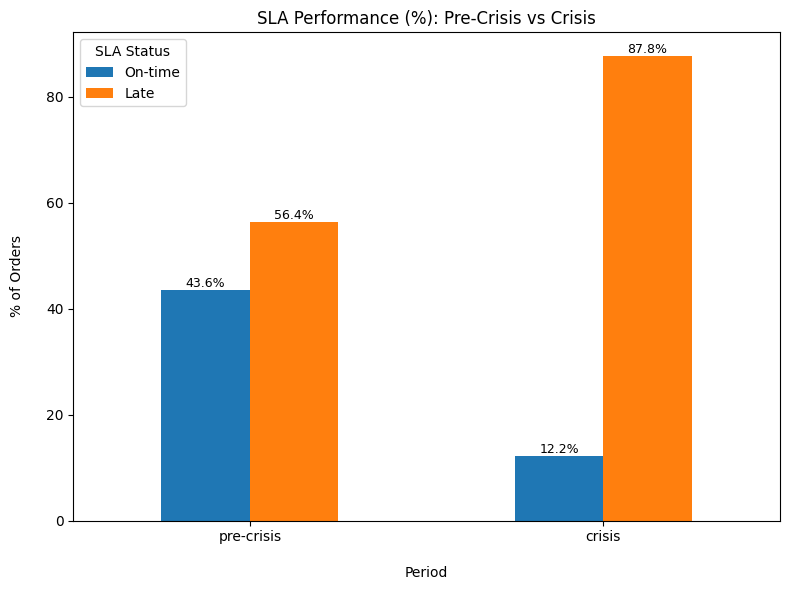

In [51]:
# Group and reshape
sla_summary = (
    df_orders_delivery_performance
    .groupby(['period','sla_breached'])
    .size()
    .unstack(fill_value=0)
    .sort_index(ascending=False)
)

# Convert counts to percentages
sla_percent = sla_summary.div(sla_summary.sum(axis=1), axis=0) * 100

# Step 4: Plot
ax = sla_percent.plot(
    kind='bar',
    figsize=(8,6),
    color=['#1f77b4','#ff7f0e']
)

# Formatting
ax.set_title("SLA Performance (%): Pre-Crisis vs Crisis", fontsize=12)
ax.set_xlabel("\nPeriod", fontsize=10)
ax.set_ylabel("% of Orders\n", fontsize=10)
ax.legend(title="SLA Status", labels=["On-time", "Late"])
plt.xticks(rotation=0)

# Add percentage labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()


In [52]:
# Averrage Delivery time
delivery_time_summary = df_orders_delivery_performance.groupby('period')['actual_delivery_time_mins'].mean().round(0)
print(delivery_time_summary)

# average expected Delivery Time
avg_time_expected = df_delivery_performance['expected_delivery_time_mins'].mean().round(0)
print('\nAverage expected delivery time : ',avg_time_expected)

period
crisis        60.0
pre-crisis    40.0
Name: actual_delivery_time_mins, dtype: float64

Average expected delivery time :  39.0


In [53]:
# Set of delivery partner id's with sla breached
late_partners = set(
    df_orders_delivery_performance.loc[
        (df_orders_delivery_performance['sla_breached'] == 'Y'),'delivery_partner_id']
)
print('Total delivery partners failed to meet SLA : ',len(late_partners))


Total delivery partners failed to meet SLA :  14967


In [54]:
# Total orders per partner
total_orders = df_orders_delivery_performance[(df_orders_delivery_performance['delivery_partner_id'].isin(late_partners))
                                              ].groupby('delivery_partner_id').size()

# SLA breached orders per partner
sla_breached_orders = df_orders_delivery_performance[
    (df_orders_delivery_performance['sla_breached'] == 'Y') &
    (df_orders_delivery_performance['delivery_partner_id'].isin(late_partners))
].groupby('delivery_partner_id').size()

#  SLA Breached Percentage Calculation
sla_breached_percentage = (sla_breached_orders/total_orders * 100).round(2)

print(sla_breached_percentage.sort_values())


delivery_partner_id
DP02117      9.09
DP02525     10.00
DP11269     11.11
DP10895     11.11
DP00791     12.50
            ...  
DP06543    100.00
DP14080    100.00
DP14977    100.00
DP09802    100.00
DP09797    100.00
Length: 14966, dtype: float64


In [55]:
# Partners with 100% breached sla
non_compilant_partner = set(sla_breached_percentage.loc[sla_breached_percentage == 100.00].index)
# Partner names
df_delivery_partner[df_delivery_partner['delivery_partner_id'].isin(non_compilant_partner)].groupby('partner_name').size()


partner_name
Amit C     2
Amit E     1
Amit F     1
Amit G     1
Amit H     1
          ..
Vikas T    1
Vikas U    1
Vikas V    1
Vikas W    1
Vikas Y    2
Length: 319, dtype: int64

In [56]:
df_orders_delivery_performance['distance_km'].sort_values().unique()

array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
       2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5,
       3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8,
       4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1,
       6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4,
       7.5, 7.6, 7.7, 7.8, 7.9, 8. ])

In [57]:
# Distance categories
# labels = ['Short (1-3 km)', 'Medium (3-5 km)', 'Long (5-8 km)']
def category(dis):
    if dis <= 3:
        return 'short'
    elif dis > 3 and dis <=5:
        return 'medium'
    else:
        return 'long'
df_orders_delivery_performance['distance_type'] = df_orders_delivery_performance['distance_km'].apply(category)
df_orders_delivery_performance.head()

,order_id,delivery_partner_id,period,is_cancelled,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,sla_breached,distance_type
0,ORD202501023439,DP05541,pre-crisis,N,31,31,6.4,N,long
1,ORD202501012051,DP08091,pre-crisis,N,46,42,1.9,Y,short
2,ORD202501019281,DP02021,pre-crisis,N,25,31,6.2,N,long
3,ORD202501000124,DP13859,pre-crisis,N,29,41,6.2,N,long
4,ORD202501006518,DP09615,pre-crisis,N,37,41,2.4,N,short


In [ ]:
df_orders_delivery_performance[(df_orders_delivery_performance['sla_breached'] == 'Y')
                               ].groupby(['distance_type']).size()

distance_type
long      40056
medium    27307
short     27863
dtype: int64

In [59]:
df = pd.merge(df_orders_delivery_performance
            [['order_id','delivery_partner_id','sla_breached','distance_km','distance_type']],
    df_delivery_partner[['delivery_partner_id','vehicle_type']],
    how="left",
    on='delivery_partner_id'
    )
df.head()

,order_id,delivery_partner_id,sla_breached,distance_km,distance_type,vehicle_type
0,ORD202501023439,DP05541,N,6.4,long,Cycle
1,ORD202501012051,DP08091,Y,1.9,short,Car
2,ORD202501019281,DP02021,N,6.2,long,Bike
3,ORD202501000124,DP13859,N,6.2,long,Cycle
4,ORD202501006518,DP09615,N,2.4,short,Scooter


In [81]:
df['delivery_partner_id'].isna().sum()

np.int64(5635)

In [87]:
sla_counts = df[(df['sla_breached'] == 'Y') & 
                (df['delivery_partner_id'].isna() == False)] \
    .groupby(['distance_type','vehicle_type']) \
    .size() \
    .reset_index(name='breach_orders')
print(sla_counts)

# total_counts = df[df['delivery_partner_id'].isna() == False] \
#     .groupby(['distance_type','vehicle_type']) \
#     .size() \
#     .reset_index(name='total_orders')

# sla_analysis = sla_counts.merge(total_counts, on=['distance_type','vehicle_type'])
# sla_analysis['breach_pct'] = (sla_analysis['breach_orders'] / sla_analysis['total_orders']) * 100
# print(sla_analysis)

   distance_type vehicle_type  breach_orders
0           long         Bike          15117
1           long          Car           2017
2           long        Cycle           5807
3           long      Scooter          15494
4         medium         Bike          10307
5         medium          Car           1355
6         medium        Cycle           3924
7         medium      Scooter          10571
8          short         Bike          10653
9          short          Car           1409
10         short        Cycle           3976
11         short      Scooter          10747


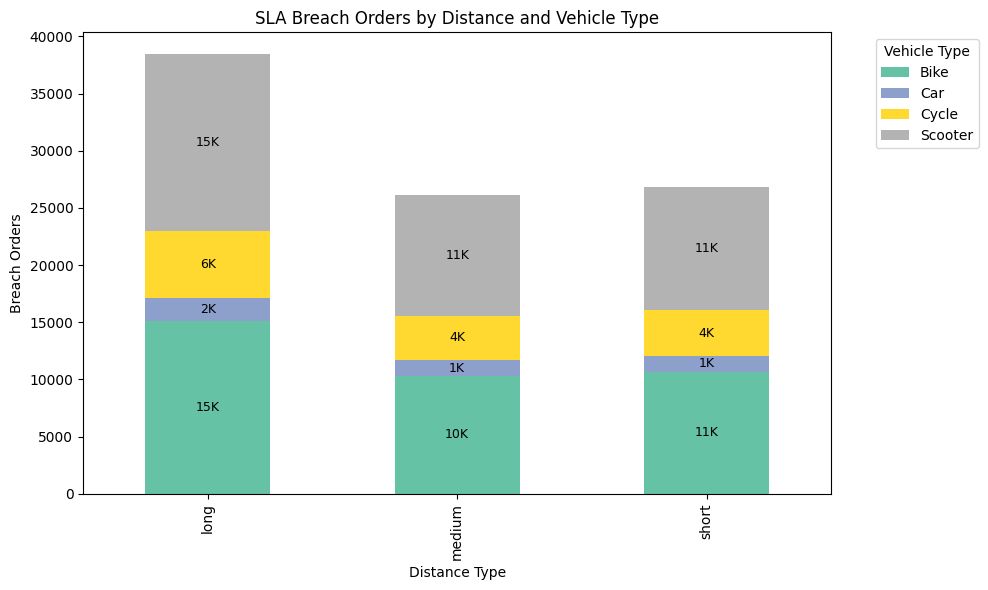

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the data so each vehicle_type becomes a column
pivot_df = sla_counts.pivot_table(
    index='distance_type',
    columns='vehicle_type',
    values='breach_orders',
    fill_value=0
)

# Plot stacked bars
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set2'
)

plt.title('SLA Breach Orders by Distance and Vehicle Type')
plt.ylabel('Breach Orders')
plt.xlabel('Distance Type')

# Add data labels on each stacked segment
for idx, row in enumerate(pivot_df.values):
    cumulative = 0
    for val in row:
        if val > 0:
            plt.text(
                idx, cumulative + val/2, f"{int(round(val/1000))}K",
                ha='center', va='center', fontsize=9, color='black'
            )
            cumulative += val

plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### 4.6 Rating Analysis

In [63]:
df_ratings.tail()

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score,month,period
68823,ORD202509009609,CUST057825,REST01490,2.2,Stale food served,2025-09-30 23:40:00,-0.40,9,crisis
68824,ORD202509004269,CUST114184,REST16601,3.6,Could be hotter,2025-09-30 23:41:00,0.30,9,crisis
68825,ORD202509006794,CUST173128,REST11207,1.2,Horrible service,2025-09-30 23:43:00,-0.90,9,crisis
68827,ORD202509008376,CUST135098,REST05223,2.1,Packaging issue,2025-09-30 23:57:00,-0.45,9,crisis
68829,ORD202509002465,CUST056144,REST19517,2.1,Food safety issue,2025-09-30 23:59:00,-0.45,9,crisis


In [64]:
df_ratings.shape[0]

68825

In [65]:
df_ratings.info()

<class 'pandas.DataFrame'>
Index: 68825 entries, 0 to 68829
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          68825 non-null  str           
 1   customer_id       68825 non-null  str           
 2   restaurant_id     68825 non-null  str           
 3   rating            68825 non-null  float64       
 4   review_text       68825 non-null  str           
 5   review_timestamp  68825 non-null  datetime64[us]
 6   sentiment_score   68825 non-null  float64       
 7   month             68825 non-null  int32         
 8   period            68825 non-null  str           
dtypes: datetime64[us](1), float64(2), int32(1), str(5)
memory usage: 5.0 MB


In [66]:
df_ratings[df_ratings['rating'].isna()]

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score,month,period


In [67]:
df_ratings['month'].astype('Int64')

0        1
1        1
2        1
3        1
4        1
        ..
68823    9
68824    9
68825    9
68827    9
68829    9
Name: month, Length: 68825, dtype: Int64

In [68]:
df_restaurant_rating = pd.merge(df_ratings
                                [['order_id','restaurant_id','rating','review_text','month']],
                                df_restaurant[['restaurant_id']],
                                how="left",
                                on='restaurant_id')
df_restaurant_rating.head()

,order_id,restaurant_id,rating,review_text,month
0,ORD202501023439,REST08622,4.5,Super fast delivery,1
1,ORD202501019281,REST14069,4.5,Great taste!,1
2,ORD202501018036,REST13907,5.0,Super fast delivery,1
3,ORD202501007724,REST08451,4.0,Tasty but a bit late,1
4,ORD202501002349,REST00225,4.4,Satisfied overall,1


In [69]:
# Top rated restaurants
by_rest = df_restaurant_rating.groupby('restaurant_id')
rating_summary = by_rest['rating'].mean()
rating_summary.nlargest(5)

restaurant_id
REST00035    5.0
REST00083    5.0
REST00163    5.0
REST00292    5.0
REST00301    5.0
Name: rating, dtype: float64

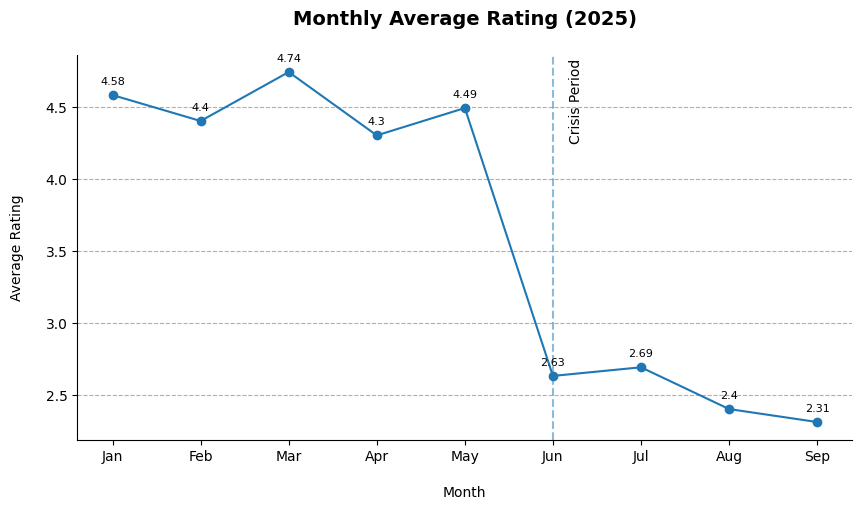

In [70]:
#Monthly avegrage rating trend
trend = df_ratings.groupby('month')['rating'].mean().round(2)
plt.figure(figsize=(10,5))

# Line chart
plt.plot(months, trend.values, marker='o')

# Title & labels
plt.title("Monthly Average Rating (2025)\n", fontsize=14, weight='bold')
plt.ylabel("Average Rating\n")
plt.xlabel("\nMonth")

# Clean look
plt.grid(axis='y', linestyle='--',alpha=1)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


for i, value in enumerate(trend.values):
    plt.annotate(
        f'{(value)}',
        (i, value),
        textcoords="offset points",
        xytext=(0, 8),   # (x_offset, y_offset)
        ha='center',
        fontsize=8
    )
    
plt.axvline(x=5, linestyle='--', alpha=0.5)
plt.text(5, max(trend) * 0.9, "\nCrisis Period", rotation=90)



plt.show()


#### 4.7 Sentiment Analysis

In [71]:
df_ratings['review_text'].value_counts()

review_text
Fresh and delicious                   6257
Excellent service                     6193
Loved it!                             6119
Super fast delivery                   6064
Great taste!                          5970
Could be hotter                       4814
Good but can improve                  4755
Tasty but a bit late                  4745
Satisfied overall                     4666
Okay experience                       4618
Food quality is not good              1962
Food safety issue                     1076
Cold food                             1073
Not worth the price                   1065
Portion size smaller than expected    1060
Average experience                    1037
Food quality not great                1017
Packaging was poor                    1001
Packaging issue                        997
Bad taste                              972
Stale food served                      971
Not recommended                        942
Very late                              904

In [72]:
df_ratings[df_ratings['sentiment_score'] < 0.5]['review_text'].value_counts()

review_text
Food quality is not good              1962
Food safety issue                     1076
Cold food                             1073
Not worth the price                   1065
Portion size smaller than expected    1060
Average experience                    1037
Food quality not great                1017
Packaging was poor                    1001
Packaging issue                        997
Bad taste                              972
Stale food served                      971
Good but can improve                   951
Not recommended                        942
Tasty but a bit late                   912
Very late                              904
Satisfied overall                      902
Could be hotter                        896
Okay experience                        859
Worst order                            156
Never again                            133
Terrible hygiene                       131
Horrible service                       127
Name: count, dtype: int64

In [73]:
print(df_ratings['sentiment_score'].min())
print(df_ratings['sentiment_score'].max())

-1.0
1.0


In [74]:
food_ratings = df_ratings[(df_ratings['review_text'].str.lower().str.contains('food'))]
food_ratings

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score,month,period
2699,ORD202501021706,CUST007175,REST17679,3.4,Cold food,2025-01-08 22:36:00,0.20,1,pre-crisis
3896,ORD202501013449,CUST088569,REST02383,3.4,Cold food,2025-01-12 00:55:00,0.20,1,pre-crisis
13201,ORD202502013225,CUST028160,REST04700,3.4,Food quality not great,2025-02-06 22:55:00,0.20,2,pre-crisis
14178,ORD202502018118,CUST064405,REST17604,3.4,Cold food,2025-02-09 16:20:00,0.20,2,pre-crisis
15044,ORD202502006553,CUST146586,REST09809,3.4,Cold food,2025-02-11 22:50:00,0.20,2,pre-crisis
...,...,...,...,...,...,...,...,...,...
68817,ORD202509005229,CUST044291,REST13405,2.7,Cold food,2025-09-30 23:14:00,-0.15,9,crisis
68818,ORD202509009136,CUST049683,REST16619,2.2,Stale food served,2025-09-30 23:22:00,-0.40,9,crisis
68820,ORD202509000417,CUST177783,REST16254,2.0,Stale food served,2025-09-30 23:29:00,-0.50,9,crisis
68823,ORD202509009609,CUST057825,REST01490,2.2,Stale food served,2025-09-30 23:40:00,-0.40,9,crisis


In [75]:
# Percentage of food complaints
food_ratings = df_ratings[(df_ratings['review_text'].str.lower().str.contains('food'))]

print('Percentage of food complaints : '
      ,food_ratings.shape[0] / df_ratings[df_ratings['sentiment_score'] < 0.5]
      .shape[0] * 100)

Percentage of food complaints :  31.85854575846218


In [76]:
# Percentage of late delivery complaints

late_count = df_ratings[(df_ratings['review_text'].str.lower().str.contains('late'))]
print('Percentage of late delivery complaints : ',
late_count.shape[0] / df_ratings[df_ratings['sentiment_score'] < 0.5]
.shape[0] * 100)

Percentage of late delivery complaints :  29.507939824488087
